# 1. Import Packages

In [20]:
import numpy as np   
import matplotlib.pyplot as plt
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2   
from minisom import MiniSom

# 2. Generate Pareto Optimal Solutions

We will use the DTLZ2 test problem to demonstrate- The NSGA2 algorithm will generate a diverse Pareto front approximation

## Pareto Front Generation

In [25]:
# Define DTLZ2 problem    
problem = get_problem("dtlz3", n_obj=4, n_var=4)  

# Optimize with NSGA2 Algorithm
algorithm = NSGA2()  
res = minimize(problem, 
               algorithm,
               ('n_gen', 100),
               seed=1,
               verbose=False)  
 
# Archive results
X = res.X # Design variables
F = res.F # Objective vectors

# 3. Train Self-Organizing Map

## SOM Generation and Training

- Dimension reduced subset of objective is mapped
- Map the 4D Pareto objective space down to 2D
- SOM topology preserves relationships
- Train SOM on objective vectors

In [26]:
# Reduce dimensions            
F = res.F[:, :3]

# Initialize Self Organizing Map
som = MiniSom(30, 30, F.shape[1])   

# Random weight initialization
som.random_weights_init(np.random.rand(100, 3)) 

# Training on objective vectors
som.train_random(F, 100)

# 4. Map Objective Space to SOM

- Project high-dimensional objective space to 2D SOM lattice
- For each 2D coordinate, find Best Matching SOM node

## Objective Space Projection Mapping

In [27]:
# Set 2D grid
x = np.linspace(0,1,30)
y = np.linspace(0,1,30)
bmu = np.zeros((len(x), len(y)))
 
# Find matching SOM node for each coordinate
for i in range(len(x)):
    for j in range(len(y)):
        bmu[i,j] = np.linalg.norm(som.get_weights()-[x[i], y[j], 0], axis=1).argmin()
        # Save index of BMU node in grid  

# 5. Visualize SOM Mapping

- Plot coordinate grid colored by Best Matching Unit index
- See projection from objective space to 2D contour

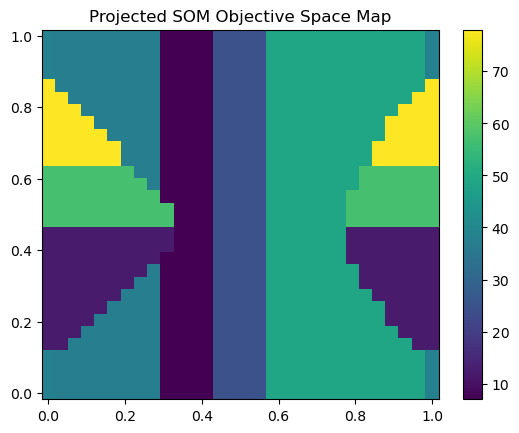

In [24]:
# Plot projection
plt.pcolor(x, y, bmu)
plt.colorbar()
plt.title("Projected SOM Objective Space Map")   
plt.show()

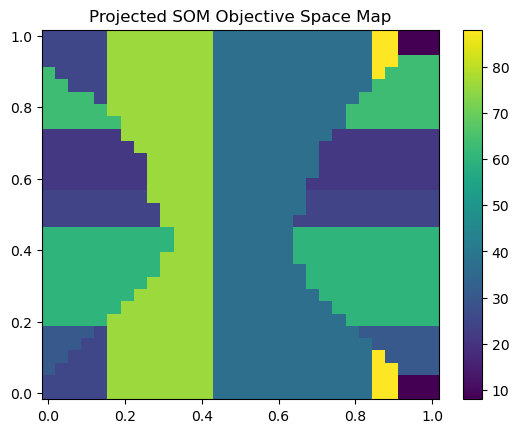

In [28]:
# Plot projection
plt.pcolor(x, y, bmu)
plt.colorbar()
plt.title("Projected SOM Objective Space Map")   
plt.show()

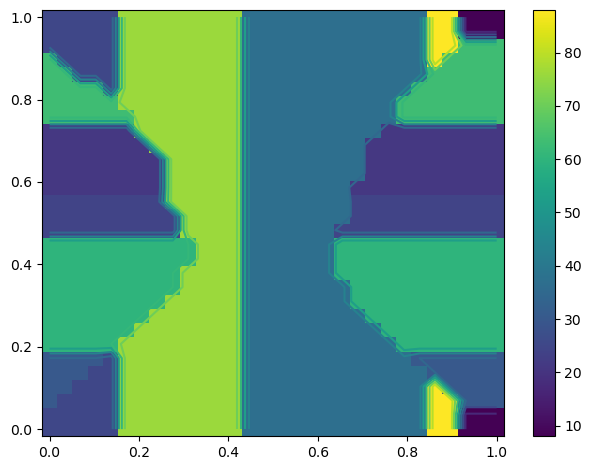

In [34]:
plt.pcolor(x, y, bmu)
plt.colorbar()
plt.contour(x,y,bmu)
plt.tight_layout()

In [ ]:
cntr = plt.contour(x,y, bmu, levels = )